In [6]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import random
import pickle

In [7]:
# Create the CartPole environment with human render mode
env = gym.make("CartPole-v1", render_mode="human")

# Reset the environment to get initial state
state, info = env.reset(seed=42)
print("Initial state (cart position, cart velocity, pole angle, pole velocity at tip):", state)

# Take a random action
action = env.action_space.sample()
print("Chosen action:", "Left" if action == 0 else "Right")

# Step the environment
next_state, reward, done, truncated, info = env.step(action)
print("After action - State:", next_state)
print("Reward:", reward, "Done:", done, "Truncated:", truncated)

# Close the environment
env.close()

Initial state (cart position, cart velocity, pole angle, pole velocity at tip): [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Chosen action: Right
After action - State: [ 0.02727336  0.18847767  0.03625453 -0.26141977]
Reward: 1.0 Done: False Truncated: False


Rendered image shape: (400, 600, 3)


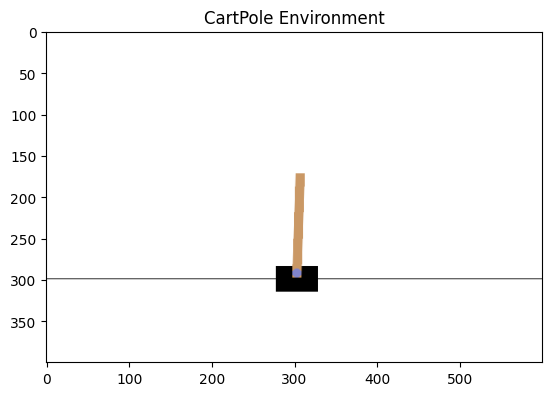

Observation Space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Observation Space bounds: [-4.8               -inf -0.41887903        -inf] to [4.8               inf 0.41887903        inf]
Observation Space dimensions: (4,)


In [8]:
# Create environment with RGB array render mode
env = gym.make("CartPole-v1", render_mode="rgb_array")

# Reset the environment
state, info = env.reset(seed=42)

# Render the environment to get RGB array
image = env.render()
print("Rendered image shape:", image.shape)

# Display the image
plt.imshow(image)
plt.title("CartPole Environment")
plt.show()

# Display observation space details
print("Observation Space:", env.observation_space)
print("Observation Space bounds:", env.observation_space.low, "to", env.observation_space.high)
print("Observation Space dimensions:", env.observation_space.shape)

# Close the environment
env.close()

In [9]:
# Define a custom initial state
# State: [cart_position, cart_velocity, pole_angle, pole_angular_velocity]
custom_state = np.array([0.0, 0.0, 0.1, 0.0])  # Slightly tilted pole (0.1 radians ~ 5.7 degrees)
print("Custom initial state to set:", custom_state)

# Create environment with human render mode
env = gym.make("CartPole-v1", render_mode="human")

# Reset with custom initial state
state, info = env.reset(options={"initial_state": custom_state})
print("Environment reset with custom state:", state)

# The human render window should show the pole slightly tilted

# Close the environment
env.close()

Custom initial state to set: [0.  0.  0.1 0. ]
Environment reset with custom state: [0.04019556 0.04686457 0.03047838 0.0452481 ]


In [10]:
import time

# Create environment with human render mode
env = gym.make("CartPole-v1", render_mode="human")

# Initialize variables
total_reward = 0
steps = 0
done = False
truncated = False

# Reset the environment
state, info = env.reset(seed=42)
print("Starting episode...")

# Run episode until done
while not (done or truncated):
    # Take random action
    action = env.action_space.sample()
    
    time.sleep(0.1)  # Slow down the rendering for better visibility
    # Step the environment
    state, reward, done, truncated, info = env.step(action)
    
    # Update counters
    total_reward += reward
    steps += 1

# Episode complete
print(f"Episode ended after {steps} steps")
print(f"Total reward: {total_reward}")
print(f"Terminated due to: {'Pole fell' if done else 'Time limit' if truncated else 'Unknown'}")

# Close the environment
env.close()

Starting episode...
Episode ended after 28 steps
Total reward: 28.0
Terminated due to: Pole fell
